In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from ugdatalab.models.apogee import APOGEEData, APOGEETrainingSet
from ugdatalab.models.apogee.constants import LABEL_NAMES, LABEL_LATEX
from ugdatalab.models.apogee.spectra import (
    _get_apstar_spectra,
    _apply_bitmask,
    _normalize_spectrum,
    _fetch_normalized_spectra,
)

import plotters

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


## Problem 1 — Training Set Selection

### Query APOGEE DR17 catalog

We query the APOGEE DR17 allStar catalog for four fields: M15 (metal-poor globular), NGC 6791 (metal-rich open cluster), a Kepler/K2 field, and a bulge field. This gives a range of stellar types and metallicities.

In [2]:
query = """
SELECT *
FROM apogeeStar AS s
JOIN aspcapStar AS a
    ON s.apstar_id = a.apstar_id
WHERE s.field IN ('M15', 'N6791', 'K2_C4_168-21', '060+00')
"""

source = APOGEEData(query)
print(f"Raw catalog: {len(source.data)} stars")
source.data[:10]

Raw catalog: 3038 stars


apstar_id,target_id,alt_id,file,apogee_id,telescope,location_id,field,ra,dec,glon,glat,apogee_target1,apogee_target2,apogee2_target1,apogee2_target2,apogee2_target3,apogee2_target4,min_h,max_h,min_jk,max_jk,survey,extratarg,nvisits,snr,starflag,andflag,vhelio_avg,vscatter,verr,rv_teff,rv_logg,rv_feh,rv_alpha,rv_carb,rv_ccfwhm,rv_autofwhm,rv_flag,n_components,gaiaedr3_source_id,gaiaedr3_parallax,gaiaedr3_parallax_error,gaiaedr3_pmra,gaiaedr3_pmra_error,gaiaedr3_pmdec,gaiaedr3_pmdec_error,gaiaedr3_phot_g_mean_mag,gaiaedr3_phot_bp_mean_mag,gaiaedr3_phot_rp_mean_mag,gaiaedr3_dr2_radial_velocity,gaiaedr3_dr2_radial_velocity_error,gaiaedr3_r_med_geo,gaiaedr3_r_lo_geo,gaiaedr3_r_hi_geo,gaiaedr3_r_med_photogeo,gaiaedr3_r_lo_photogeo,gaiaedr3_r_hi_photogeo,htmID,apogee_id1,target_id1,apstar_id1,aspcap_id,teff,teff_err,teff_flag,teff_spec,logg,logg_err,logg_flag,logg_spec,vmicro,vmacro,vsini,m_h,m_h_err,m_h_flag,alpha_m,alpha_m_err,alpha_m_flag,aspcap_chi2,aspcap_grid,aspcapflag,frac_badpix,frac_lowsnr,frac_sigsky,fparam_teff,fparam_logg,fparam_logvmicro,fparam_m_h,fparam_c_m,fparam_n_m,fparam_alpha_m,param_c_m,param_c_m_flag,param_n_m,param_n_m_flag,c_fe,c_fe_err,c_fe_flag,ci_fe,ci_fe_err,ci_fe_flag,n_fe,n_fe_err,n_fe_flag,o_fe,o_fe_err,o_fe_flag,na_fe,na_fe_err,na_fe_flag,mg_fe,mg_fe_err,mg_fe_flag,al_fe,al_fe_err,al_fe_flag,si_fe,si_fe_err,si_fe_flag,p_fe,p_fe_err,p_fe_flag,s_fe,s_fe_err,s_fe_flag,k_fe,k_fe_err,k_fe_flag,ca_fe,ca_fe_err,ca_fe_flag,ti_fe,ti_fe_err,ti_fe_flag,tiii_fe,tiii_fe_err,tiii_fe_flag,v_fe,v_fe_err,v_fe_flag,cr_fe,cr_fe_err,cr_fe_flag,mn_fe,mn_fe_err,mn_fe_flag,fe_h,fe_h_err,fe_h_flag,co_fe,co_fe_err,co_fe_flag,ni_fe,ni_fe_err,ni_fe_flag,cu_fe,cu_fe_err,cu_fe_flag,ce_fe,ce_fe_err,ce_fe_flag,felem_c_m,felem_c_m_err,felem_ci_m,felem_ci_m_err,felem_n_m,felem_n_m_err,felem_o_m,felem_o_m_err,felem_na_h,felem_na_h_err,felem_mg_m,felem_mg_m_err,felem_al_h,felem_al_h_err,felem_si_m,felem_si_m_err,felem_p_m,felem_p_m_err,felem_s_m,felem_s_m_err,felem_k_h,felem_k_h_err,felem_ca_m,felem_ca_m_err,felem_ti_m,felem_ti_m_err,felem_tiii_m,felem_tiii_m_err,felem_v_h,felem_v_h_err,felem_cr_h,felem_cr_h_err,felem_mn_h,felem_mn_h_err,felem_fe_h,felem_fe_h_err,felem_co_h,felem_co_h_err,felem_ni_h,felem_ni_h_err,felem_cu_h,felem_cu_h_err,felem_ge_h,felem_ge_h_err,felem_rb_h,felem_rb_h_err,felem_ce_h,felem_ce_h_err,felem_nd_h,felem_nd_h_err,felem_yb_h,felem_yb_h_err
str51,str38,str4,str35,str18,str6,int64,str12,float64,float64,float64,float64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,str36,int64,int64,float64,int64,int64,float64,float64,float64,float64,float64,float64,int64,int64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,str18,str38,str51,str53,float64,float64,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64,float64,float64,int64,float64,str5,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,int64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,int64,float64,int64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,float64,float64,float64,float64,int64,int64,float64,float64
apogee.apo25

### Apply quality cuts

We select a training set by requiring:
- All 5 ASPCAP labels (Teff, log g, [Fe/H], [Mg/Fe], [Si/Fe]) finite and not the ASPCAP NULL sentinel ($-9999$)
- SNR $> 50$
- $\log g \leq 4$ and $T_{\rm eff} \leq 5700\,\mathrm{K}$ (giants only)
- $[\mathrm{Fe/H}] \geq -1$

In [3]:
training = APOGEETrainingSet(source)
print(f"After quality cuts: {len(training.data)} stars")
training.data[:10]

After quality cuts: 1886 stars


apstar_id,target_id,alt_id,file,apogee_id,telescope,location_id,field,ra,dec,glon,glat,apogee_target1,apogee_target2,apogee2_target1,apogee2_target2,apogee2_target3,apogee2_target4,min_h,max_h,min_jk,max_jk,survey,extratarg,nvisits,snr,starflag,andflag,vhelio_avg,vscatter,verr,rv_teff,rv_logg,rv_feh,rv_alpha,rv_carb,rv_ccfwhm,rv_autofwhm,rv_flag,n_components,gaiaedr3_source_id,gaiaedr3_parallax,gaiaedr3_parallax_error,gaiaedr3_pmra,gaiaedr3_pmra_error,gaiaedr3_pmdec,gaiaedr3_pmdec_error,gaiaedr3_phot_g_mean_mag,gaiaedr3_phot_bp_mean_mag,gaiaedr3_phot_rp_mean_mag,gaiaedr3_dr2_radial_velocity,gaiaedr3_dr2_radial_velocity_error,gaiaedr3_r_med_geo,gaiaedr3_r_lo_geo,gaiaedr3_r_hi_geo,gaiaedr3_r_med_photogeo,gaiaedr3_r_lo_photogeo,gaiaedr3_r_hi_photogeo,htmID,apogee_id1,target_id1,apstar_id1,aspcap_id,teff,teff_err,teff_flag,teff_spec,logg,logg_err,logg_flag,logg_spec,vmicro,vmacro,vsini,m_h,m_h_err,m_h_flag,alpha_m,alpha_m_err,alpha_m_flag,aspcap_chi2,aspcap_grid,aspcapflag,frac_badpix,frac_lowsnr,frac_sigsky,fparam_teff,fparam_logg,fparam_logvmicro,fparam_m_h,fparam_c_m,fparam_n_m,fparam_alpha_m,param_c_m,param_c_m_flag,param_n_m,param_n_m_flag,c_fe,c_fe_err,c_fe_flag,ci_fe,ci_fe_err,ci_fe_flag,n_fe,n_fe_err,n_fe_flag,o_fe,o_fe_err,o_fe_flag,na_fe,na_fe_err,na_fe_flag,mg_fe,mg_fe_err,mg_fe_flag,al_fe,al_fe_err,al_fe_flag,si_fe,si_fe_err,si_fe_flag,p_fe,p_fe_err,p_fe_flag,s_fe,s_fe_err,s_fe_flag,k_fe,k_fe_err,k_fe_flag,ca_fe,ca_fe_err,ca_fe_flag,ti_fe,ti_fe_err,ti_fe_flag,tiii_fe,tiii_fe_err,tiii_fe_flag,v_fe,v_fe_err,v_fe_flag,cr_fe,cr_fe_err,cr_fe_flag,mn_fe,mn_fe_err,mn_fe_flag,fe_h,fe_h_err,fe_h_flag,co_fe,co_fe_err,co_fe_flag,ni_fe,ni_fe_err,ni_fe_flag,cu_fe,cu_fe_err,cu_fe_flag,ce_fe,ce_fe_err,ce_fe_flag,felem_c_m,felem_c_m_err,felem_ci_m,felem_ci_m_err,felem_n_m,felem_n_m_err,felem_o_m,felem_o_m_err,felem_na_h,felem_na_h_err,felem_mg_m,felem_mg_m_err,felem_al_h,felem_al_h_err,felem_si_m,felem_si_m_err,felem_p_m,felem_p_m_err,felem_s_m,felem_s_m_err,felem_k_h,felem_k_h_err,felem_ca_m,felem_ca_m_err,felem_ti_m,felem_ti_m_err,felem_tiii_m,felem_tiii_m_err,felem_v_h,felem_v_h_err,felem_cr_h,felem_cr_h_err,felem_mn_h,felem_mn_h_err,felem_fe_h,felem_fe_h_err,felem_co_h,felem_co_h_err,felem_ni_h,felem_ni_h_err,felem_cu_h,felem_cu_h_err,felem_ge_h,felem_ge_h_err,felem_rb_h,felem_rb_h_err,felem_ce_h,felem_ce_h_err,felem_nd_h,felem_nd_h_err,felem_yb_h,felem_yb_h_err
str51,str38,str4,str35,str18,str6,int64,str12,float64,float64,float64,float64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,str36,int64,int64,float64,int64,int64,float64,float64,float64,float64,float64,float64,int64,int64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,str18,str38,str51,str53,float64,float64,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64,float64,float64,int64,float64,str5,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,int64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,int64,float64,int64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,float64,float64,float64,float64,int64,int64,float64,float64
apogee.apo25

### Surface gravity calculation

Surface gravity is $g = GM/R^2$. For a solar-mass star:

$$\log g = \log g_\odot + \log\left(\frac{M}{M_\odot}\right) - 2\log\left(\frac{R}{R_\odot}\right)$$

where $\log g_\odot = 4.44$ (CGS). Typical evolutionary stages:

| Stage | $R/R_\odot$ | $\log g$ |
|---|---|---|
| Main sequence | $\sim 1$ | $\sim 4.44$ |
| Pre-He flash (tip RGB) | $\sim 100$ | $\sim 0.44$ |
| Core He burning (red clump) | $\sim 15$ | $\sim 2.08$ |

The $\log g \leq 4$ cut selects evolved stars (giants and subgiants), excluding the main sequence. Most of our sample will be red giants on the RGB or in the red clump.

### Label corner plot

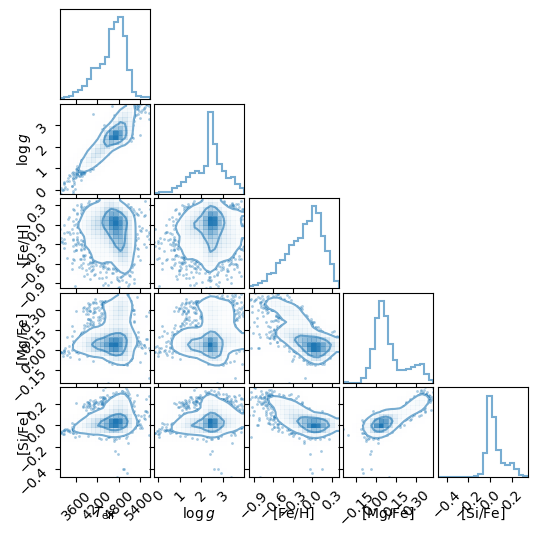

In [4]:
label_cols = ["teff", "logg", "fe_h", "mg_fe", "si_fe"]
labels = np.column_stack([training.data[col] for col in label_cols])

fig = plotters.plot_label_corner(labels, LABEL_LATEX)
plt.show()

## Problem 2 — Download Spectra

### Raw spectrum example

We download one spectrum to examine before normalization. APOGEE spectra are in units of $10^{-17}\,\mathrm{erg\,s^{-1}\,cm^{-2}\,\AA^{-1}}$ (spectral flux density) on a barycentric wavelength grid — observed wavelengths corrected for Earth's orbital motion so that absorption features appear at their rest wavelengths.

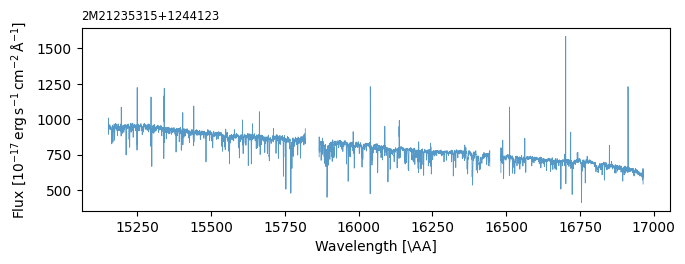

In [5]:
example_id = "2M21235315+1244123"
example_row = training.data[np.array(training.data["apogee_id"], dtype=str) == example_id]
spec_raw = _get_apstar_spectra(
    example_id,
    str(example_row["telescope"][0]),
    str(example_row["field"][0]),
)

ax = plotters.plot_example_spectrum(spec_raw["wavelength"], spec_raw["flux"], apogee_id=example_id)
plt.show()

## Problem 3 — Pixel Bitmask

The APOGEE pixel bitmask flags problematic pixels:
- **Bits 0–7**: bad detector pixels, cosmic rays, saturation, persistence, sky subtraction failures
- **Bit 12**: unvisited pixels (gaps between chips)

Setting $\sigma_\lambda = \infty$ for flagged pixels gives them zero weight ($1/\sigma^2 = 0$) in any subsequent chi-squared fit, effectively masking them without discarding the entire spectrum.

## Problem 4 — Pseudo-Continuum Normalization

Pseudo-continuum normalization divides each spectrum by a smooth estimate of the underlying continuum level. "Pseudo" because we use empirically identified continuum pixels — wavelengths where the flux does not depend on stellar labels — rather than a physical stellar atmosphere model for the true continuum. This removes the broadband SED shape (set by effective temperature and the instrument's blaze function) so that spectral features can be modeled as fractional deviations from unity.

We fit an independent degree-4 Chebyshev polynomial to each of the three APOGEE chips (blue, green, red), using only the 529 pre-identified continuum pixels. Each chip gets its own polynomial — no polynomial spans across inter-chip gaps.

### Normalization diagnostic

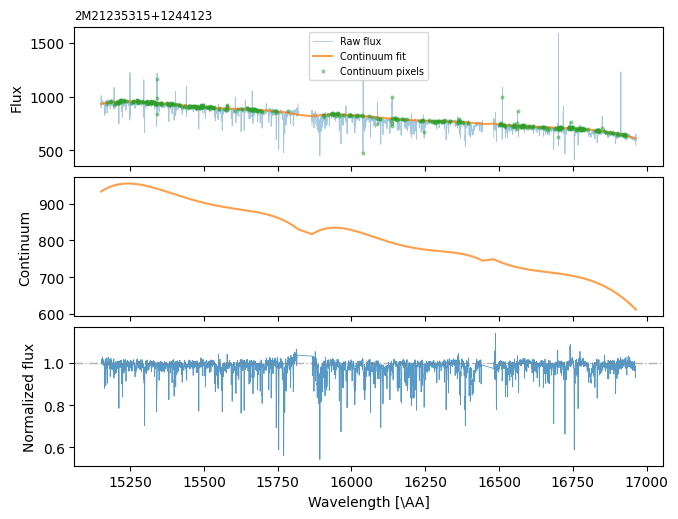

In [6]:
continuum_path = Path("../../course_materials_sp2026/labs/lab_2/continuum_wavelengths.npz")
continuum_data = np.load(continuum_path)
continuum_mask = continuum_data["continuum"].astype(bool)
wavelength = continuum_data["wavelengths"]

flux_masked, error_masked = _apply_bitmask(
    spec_raw["flux"], spec_raw["error"], spec_raw["bitmask"],
)
flux_norm, error_norm, continuum_fit = _normalize_spectrum(
    flux_masked, error_masked, wavelength, continuum_mask,
    spec_raw["chips"], degree=4,
)

axes = plotters.plot_normalization_diagnostic(
    wavelength, spec_raw["flux"], spec_raw["error"],
    continuum_fit, flux_norm, error_norm, continuum_mask,
    apogee_id=example_id,
)
plt.show()

### Download and normalize all training spectra

In [7]:
flux, error, wavelength, continuum_mask, apogee_ids = _fetch_normalized_spectra(
    training.data, continuum_path, degree=4, max_workers=4,
)
print(f"Flux shape: {flux.shape}")
print(f"Error shape: {error.shape}")
print(f"Wavelength shape: {wavelength.shape}")
print(f"Stars downloaded: {len(apogee_ids)}")

APOGEE spectra:   0%|          | 0/1886 [00:00<?, ?it/s]

Flux shape: (1886, 8575)
Error shape: (1886, 8575)
Wavelength shape: (8575,)
Stars downloaded: 1886


### Robustness check — similar stars comparison

Stars with similar labels should produce nearly identical normalized spectra. Significant differences would indicate problems with the continuum normalization.

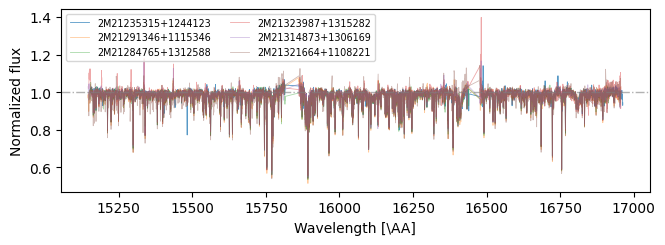

In [8]:
# The spectra are downloaded in catalog order, so apogee_ids matches training.data order.
# Build label array directly from catalog order.
label_cols = ["teff", "logg", "fe_h", "mg_fe", "si_fe"]
spec_labels = np.column_stack([training.data[col] for col in label_cols])

# Use the example star as reference
ref_idx = int(np.where(apogee_ids == example_id)[0][0])

ax = plotters.plot_similar_stars_comparison(
    wavelength, flux, error, spec_labels, apogee_ids, ref_idx, n_similar=5,
)
plt.show()

### Save training spectra

In [9]:
# Labels are in catalog order (same as spectra download order)
labels_all = np.column_stack([training.data[col] for col in label_cols])
starflag = np.array(training.data["starflag"])
aspcapflag = np.array(training.data["aspcapflag"])

np.savez_compressed(
    "training_spectra.npz",
    wavelength=wavelength,
    flux=flux,
    error=error,
    labels=labels_all,
    label_names=np.array(LABEL_NAMES),
    apogee_ids=apogee_ids,
    continuum_mask=continuum_mask,
    starflag=starflag,
    aspcapflag=aspcapflag,
)
print("Saved training_spectra.npz")
print(f"  flux: {flux.shape}")
print(f"  labels: {labels_all.shape}")
print(f"  stars: {len(apogee_ids)}")

Saved training_spectra.npz
  flux: (1886, 8575)
  labels: (1886, 5)
  stars: 1886
